In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [131]:
df = pd.read_csv("../data/raw/superstore.csv")



## Data Understanding

In [132]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [134]:
df.shape

(9800, 18)

In [135]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [136]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

In [137]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"],dayfirst= True)

In [138]:
df.duplicated().sum()

np.int64(0)

In [139]:
df.isnull().sum()


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [140]:
df['Postal Code'] = df.groupby('City')['Postal Code'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else None)
)

In [141]:
df=df.drop(['Row ID','Customer ID', 'Product ID'],axis=1)

In [142]:
df['Postal Code']=df['Postal Code'].astype(int)

In [143]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Product Name,Sales
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9800 non-null   object        
 1   Order Date     9800 non-null   datetime64[ns]
 2   Ship Date      9800 non-null   datetime64[ns]
 3   Ship Mode      9800 non-null   object        
 4   Customer Name  9800 non-null   object        
 5   Segment        9800 non-null   object        
 6   Country        9800 non-null   object        
 7   City           9800 non-null   object        
 8   State          9800 non-null   object        
 9   Postal Code    9800 non-null   int64         
 10  Region         9800 non-null   object        
 11  Category       9800 non-null   object        
 12  Sub-Category   9800 non-null   object        
 13  Product Name   9800 non-null   object        
 14  Sales          9800 non-null   float64       
dtypes: datetime64[ns](2),

In [145]:
df.describe()

,Order Date,Ship Date,Postal Code,Sales
count,9800,9800,9800.000000,9800.000000
mean,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55241.830612,230.769059
min,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000
25%,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000
50%,2017-06-26 00:00:00,2017-06-29 00:00:00,57551.000000,54.490000
75%,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000
max,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000
std,NaN,NaN,32037.012522,626.651875


In [146]:
df['Country'].value_counts()

Country
United States    9800
Name: count, dtype: int64

In [147]:
df=df.drop(['Country'],axis=1)

In [148]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Postal Code,Region,Category,Sub-Category,Product Name,Sales
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,Claire Gute,Consumer,Henderson,Kentucky,42420,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,Claire Gute,Consumer,Henderson,Kentucky,42420,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,Darrin Van Huff,Corporate,Los Angeles,California,90036,West,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [149]:
df.to_csv("../data/processed/Superstore_processed.csv", index=False)

In [150]:
total_revenue = df["Sales"].sum()
total_revenue


np.float64(2261536.7827)

In [151]:
total_orders = len(df)
total_orders

9800

In [152]:
df["Order ID"].nunique()

4922

In [154]:
df["Customer Name"].nunique()

793

In [153]:
#Average Order Value (AOV)
aov = df["Sales"].sum() / df["Order ID"].nunique()
aov

np.float64(459.4751691791954)

In [157]:
#Average Revenue per Customer
customer_revenue = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .mean()
)
customer_revenue

np.float64(2851.8748836065574)

In [179]:
df.groupby('Region')['Sales'].sum().sort_values()

Region
South      389151.4590
Central    492646.9132
East       669518.7260
West       710219.6845
Name: Sales, dtype: float64

In [102]:
df.groupby('State')['Sales'].sum().sort_values()

State
North Dakota               919.9100
West Virginia             1209.8240
Maine                     1270.5300
South Dakota              1315.5600
Wyoming                   1603.1360
District of Columbia      2865.0200
Kansas                    2914.3100
Idaho                     4382.4860
Iowa                      4443.5600
New Mexico                4783.5220
Montana                   5589.3520
New Hampshire             7292.5240
Nebraska                  7464.9300
South Carolina            8481.7100
Vermont                   8929.3700
Louisiana                 9131.0500
Mississippi              10771.3400
Utah                     11220.0560
Arkansas                 11678.1300
Connecticut              13384.3570
Nevada                   16729.1020
Oregon                   17284.4620
Alabama                  19510.6400
Oklahoma                 19683.3900
Missouri                 22205.1500
Rhode Island             22525.0260
Maryland                 23705.5230
Delaware              

In [177]:
df.groupby('Category')['Sales'].sum().sort_values()

Category
Office Supplies    705422.3340
Furniture          728658.5757
Technology         827455.8730
Name: Sales, dtype: float64

In [158]:
df.groupby('Sub-Category')['Sales'].sum()

Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Chairs         322822.7310
Copiers        146248.0940
Envelopes       16128.0460
Fasteners        3001.9600
Furnishings     89212.0180
Labels          12347.7260
Machines       189238.6310
Paper           76828.3040
Phones         327782.4480
Storage        219343.3920
Supplies        46420.3080
Tables         202810.6280
Name: Sales, dtype: float64

In [160]:
df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

Order Date
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040


## KPI Analysis

### Total Sales（总销售额）

In [161]:
total_sales = df["Sales"].sum()
print(f"${total_sales:,.2f}")

$2,261,536.78


In [162]:
# Monthly Sales Trend（
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

<Axes: xlabel='Order Date'>

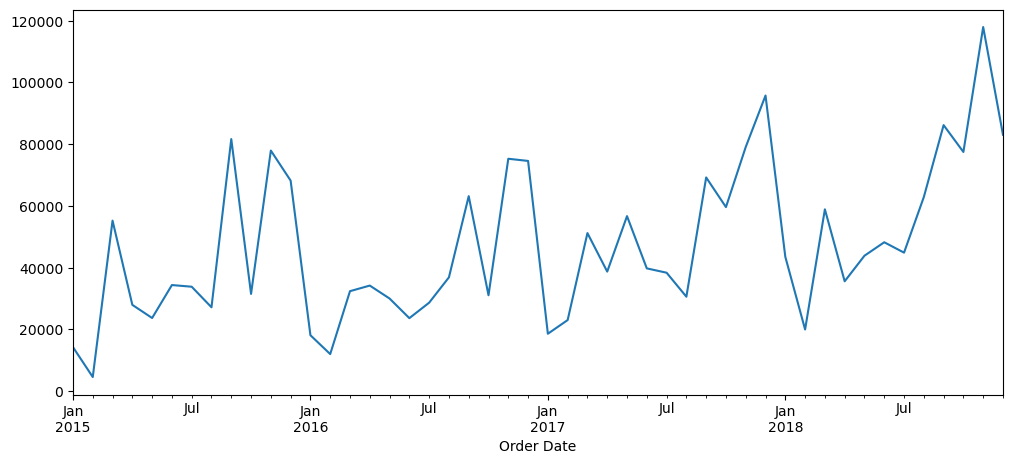

In [113]:
monthly_sales.plot(figsize=(12,5))

### Customer Analysis 

In [116]:
df["Customer Name"].nunique()

793

In [122]:
avg_customer_value = (
    df.groupby("Customer Name")["Sales"]
      .sum().mean()

)
avg_customer_value

np.float64(2851.8748836065574)

In [164]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)
monthly_sales

Order Date
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040


In [166]:
monthly_growth = monthly_sales.pct_change() * 100
monthly_growth 

Order Date
2015-01            NaN
2015-02     -68.182562
2015-03    1121.396374
2015-04     -49.449412
2015-05     -15.274211
2015-06      45.163660
2015-07      -1.577349
2015-08     -19.726768
2015-09     200.999048
2015-10     -61.465286
2015-11     147.692389
2015-12     -12.502753
2016-01     -73.496058
2016-02     -33.849344
2016-03     170.589961
2016-04       5.612827
2016-05     -12.282252
2016-06     -21.229159
2016-07      21.224652
2016-08      28.698297
2016-09      71.473245
2016-10     -50.879192
2016-11     142.648125
2016-12      -0.937945
2017-01     -75.125308
2017-02      23.925178
2017-03     122.661869
2017-04     -24.401989
2017-05      46.476860
2017-06     -29.885891
2017-07      -3.533596
2017-08     -20.298601
2017-09     126.550118
2017-10     -13.889127
2017-11      32.699683
2017-12      21.086840
2018-01     -54.588601
2018-02     -54.179823
2018-03     195.484265
2018-04     -39.619692
2018-05      23.307898
2018-06       9.959265
2018-07      -6.983965


In [170]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64